2025-08-28 23:23:45.290969: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-28 23:23:48.212687: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-28 23:23:48.220245: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-28 23:23:51.585306: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Found 9955 validated image filenames belonging to 4 classes.
Found 1244 validated image filenames belonging to 4 classes.
Found 1245 validated image filenames belonging to 4 classes.


2025-08-28 23:24:01.271079: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 95551488 exceeds 10% of free system memory.
2025-08-28 23:24:01.389426: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 95551488 exceeds 10% of free system memory.
2025-08-28 23:24:01.513229: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 95551488 exceeds 10% of free system memory.
2025-08-28 23:24:02.742119: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 38535168 exceeds 10% of free system memory.


Epoch 1/10


2025-08-28 23:24:03.220201: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 95551488 exceeds 10% of free system memory.


156/156 [==============================] - 767s 5s/step - loss: 0.2816 - accuracy: 0.9049 - val_loss: 0.0316 - val_accuracy: 0.9984
Epoch 2/10
156/156 [==============================] - 789s 5s/step - loss: 0.0119 - accuracy: 0.9995 - val_loss: 0.0042 - val_accuracy: 1.0000
Epoch 3/10
156/156 [==============================] - 628s 4s/step - loss: 0.0022 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 4/10
156/156 [==============================] - 1031s 7s/step - loss: 9.8550e-04 - accuracy: 1.0000 - val_loss: 0.0010 - val_accuracy: 1.0000
Epoch 5/10
156/156 [==============================] - 774s 5s/step - loss: 5.7500e-04 - accuracy: 1.0000 - val_loss: 6.4128e-04 - val_accuracy: 1.0000
Epoch 6/10
156/156 [==============================] - 940s 6s/step - loss: 3.6983e-04 - accuracy: 1.0000 - val_loss: 4.5008e-04 - val_accuracy: 1.0000
Epoch 7/10
156/156 [==============================] - 788s 5s/step - loss: 2.5790e-04 - accuracy: 1.0000 - val_loss: 3.4245e-04 - va

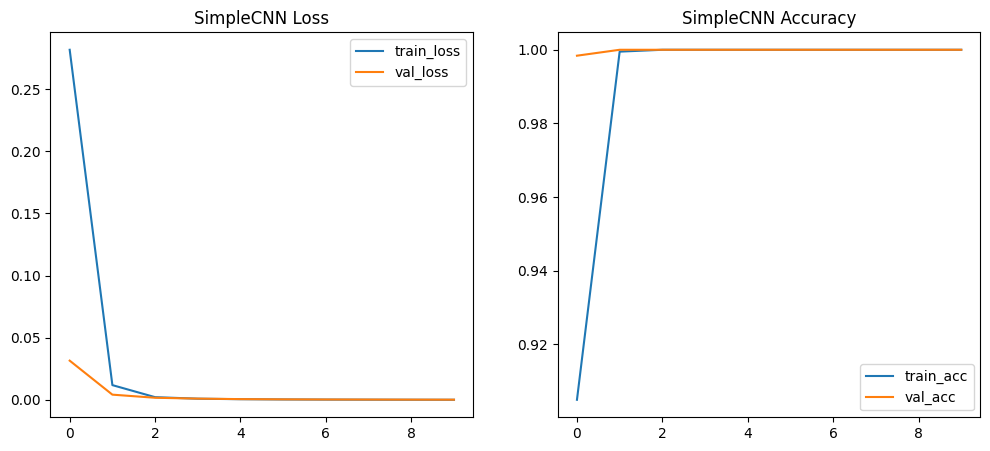

20/20 [==============================] - 20s 882ms/step


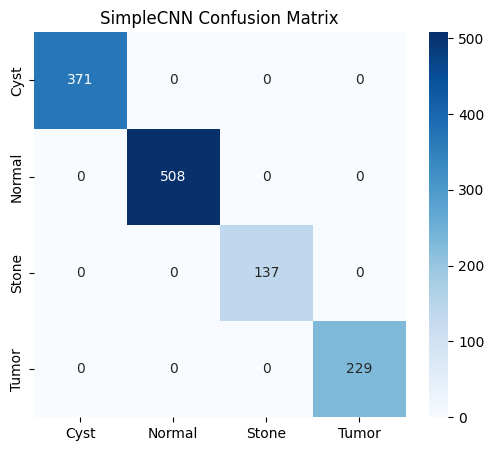


SimpleCNN Classification Report:

              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       371
      Normal       1.00      1.00      1.00       508
       Stone       1.00      1.00      1.00       137
       Tumor       1.00      1.00      1.00       229

    accuracy                           1.00      1245
   macro avg       1.00      1.00      1.00      1245
weighted avg       1.00      1.00      1.00      1245



/home/ramanauzumaki/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ SimpleCNN saved as simplecnn_kidney.h5
Epoch 1/10


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D,
                                     Input, Conv2DTranspose, concatenate)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

DATASET_DIR = "/media/sf_ramana777/Downloads/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/"

def create_dataframe(dataset_dir):
    filepaths, labels = [], []
    for cls in os.listdir(dataset_dir):
        cls_path = os.path.join(dataset_dir, cls)
        for img in os.listdir(cls_path):
            filepaths.append(os.path.join(cls_path, img))
            labels.append(cls)
    return pd.DataFrame({"filepath": filepaths, "labels": labels})

def split_dataframe(df, test_size=0.2, val_size=0.5, seed=42):
    train_df, dummy_df = train_test_split(
        df, test_size=test_size, random_state=seed, stratify=df["labels"]
    )
    valid_df, test_df = train_test_split(
        dummy_df, test_size=val_size, random_state=seed, stratify=dummy_df["labels"]
    )
    return train_df, valid_df, test_df

def build_generators(train_df, valid_df, test_df, img_size=(224,224), batch_size=64):
    datagen = ImageDataGenerator(rescale=1./255)
    train_gen = datagen.flow_from_dataframe(train_df, x_col="filepath", y_col="labels",
                                            target_size=img_size, class_mode="categorical",
                                            shuffle=True, batch_size=batch_size)
    valid_gen = datagen.flow_from_dataframe(valid_df, x_col="filepath", y_col="labels",
                                            target_size=img_size, class_mode="categorical",
                                            shuffle=True, batch_size=batch_size)
    test_gen = datagen.flow_from_dataframe(test_df, x_col="filepath", y_col="labels",
                                           target_size=img_size, class_mode="categorical",
                                           shuffle=False, batch_size=batch_size)
    return train_gen, valid_gen, test_gen

def build_simple_cnn(input_shape=(224,224,3), num_classes=4):
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation="relu"),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])
    return model

def plot_history(history, name):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{name} Loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{name} Accuracy"); plt.legend()
    plt.show()

def train_and_evaluate(model, train_gen, valid_gen, test_gen, class_labels, name):
    model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
    history = model.fit(train_gen, validation_data=valid_gen, epochs=10, callbacks=[es], verbose=1)
    plot_history(history, name)
    preds = np.argmax(model.predict(test_gen), axis=1)
    cm = confusion_matrix(test_gen.classes, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"{name} Confusion Matrix"); plt.show()
    print(f"\n{name} Classification Report:\n")
    print(classification_report(test_gen.classes, preds, target_names=class_labels))
    test_acc = model.evaluate(test_gen, verbose=0)[1]
    model.save(f"{name.lower()}_kidney.h5")
    print(f"✅ {name} saved as {name.lower()}_kidney.h5")
    return test_acc

def main():
    df = create_dataframe(DATASET_DIR)
    train_df, valid_df, test_df = split_dataframe(df)
    train_gen, valid_gen, test_gen = build_generators(train_df, valid_df, test_df)
    class_labels = list(train_gen.class_indices.keys())

    cnn = build_simple_cnn(num_classes=len(class_labels))
    cnn_acc = train_and_evaluate(cnn, train_gen, valid_gen, test_gen, class_labels, "SimpleCNN")

    print("\n📊 Test Accuracy Comparison")
    print(f"SimpleCNN: {cnn_acc*100:.2f}%")

if __name__ == "__main__":
    main()

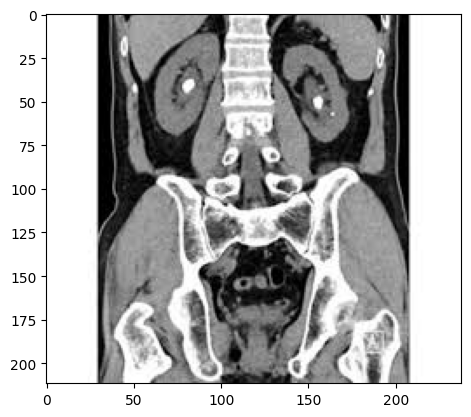

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
Predicted class: Stone (Confidence: 1.00)


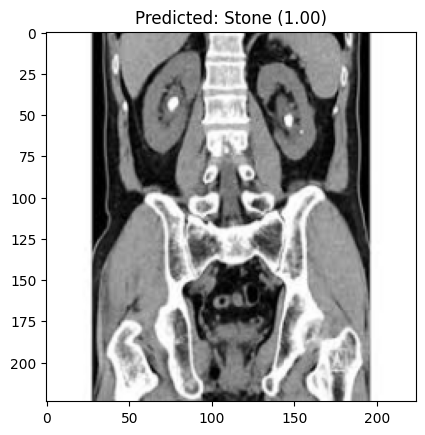

In [5]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import warnings
warnings.filterwarnings("ignore")

img_path = "C:\\Users\\ramana777\\OneDrive\\Desktop\\kidney_stone.jpg"
img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()
img = tf.image.resize(img, [224, 224])  
img = img / 255.0                 
img = np.expand_dims(img, axis=0) 

model = tf.keras.models.load_model("simplecnn_kidney.h5")

pred = model.predict(img)

class_names = ["Cyst","Normal","Stone","Tumor"]
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

print(f"Predicted class: {predicted_class} (Confidence: {confidence:.2f})")
plt.imshow(img[0])
plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
plt.show()

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,907,910 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)